# Music Classification — Unsupervised + Supervised

Vertrekt vanuit `combined.csv` en classificeert songs zonder vooraf gedefinieerde labels.

**Aanpak:**
1. **K-Means clustering** — groepeert songs op basis van audio features (unsupervised)
2. **Random Forest classifier** — getraind op de K-Means clusters als labels (supervised)

Na afloop interpreteer je welke cluster 'calm', 'neutral' en 'energy' is op basis van de cluster-gemiddelden.

---

## 1. Imports

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

In [48]:
os.getcwd()


'c:\\Users\\astri\\Desktop\\Data_Scientist\\Eindwerk\\spotify-project\\docs\\playgrounds\\av_playground\\music_class_ml'

---
## 2. Instellingen

In [49]:
# ══════════════════════════════════════════════════════════════════════════════
#  PAD
# ══════════════════════════════════════════════════════════════════════════════
PARTICIPANT = "courgette"
CSV_PATH = Path(f"../../../../data/playlists/{PARTICIPANT}/playlists_generated/combined.csv")   

# ══════════════════════════════════════════════════════════════════════════════
#  FEATURES die gebruikt worden voor clustering & classificatie
#  Verwijder features die niet in jouw CSV staan
# ══════════════════════════════════════════════════════════════════════════════
FEATURES = [
    'tempo',
    'energy',
    'acousticness',
    'valence',
    'loudness',
    'danceability',
    'instrumentalness',
    'speechiness',
]

# ══════════════════════════════════════════════════════════════════════════════
#  CLUSTERING
# ══════════════════════════════════════════════════════════════════════════════
N_CLUSTERS = 8

# ══════════════════════════════════════════════════════════════════════════════
#  RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
N_ESTIMATORS = 200    # aantal bomen
TEST_SIZE    = 0.25   # 25% voor testen

print("Instellingen geladen OK")

Instellingen geladen OK


---
## 3. Data laden & voorbereiden

In [50]:
df = pd.read_csv(CSV_PATH)
print(f"Geladen: {len(df)} songs")
print(f"Kolommen: {list(df.columns)}")

# Alleen features behouden die aanwezig zijn in de CSV
features_available = [f for f in FEATURES if f in df.columns]
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    print(f"\nNiet gevonden in CSV (worden genegeerd): {missing}")
print(f"Gebruikte features: {features_available}")

# Rijen met NaN verwijderen
df_model = df[features_available].dropna()
dropped = len(df) - len(df_model)
if dropped:
    print(f"Verwijderd wegens NaN: {dropped} rijen")
print(f"\nBeschikbaar voor modellen: {len(df_model)} songs")

# Normaliseren (belangrijk voor K-Means en PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)
print("Features genormaliseerd (StandardScaler) OK")

Geladen: 3089 songs
Kolommen: ['uri', 'name', 'album', 'artists', 'Release Date', 'duration_ms', 'Popularity', 'Explicit', 'Added By', 'Added At', 'Genres', 'Record Label', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Gebruikte features: ['tempo', 'energy', 'acousticness', 'valence', 'loudness', 'danceability', 'instrumentalness', 'speechiness']

Beschikbaar voor modellen: 3089 songs
Features genormaliseerd (StandardScaler) OK


---
## 4. Model A — K-Means Clustering
Groepeert songs puur op basis van audio features, zonder labels.

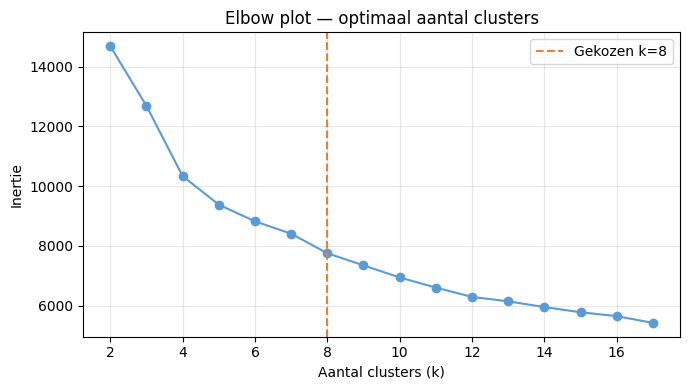

In [51]:
# ── Elbow plot: inertie per aantal clusters ───────────────────────────────────
inertias = []
k_range = range(2, 18)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='#5b9bd5')
ax.axvline(N_CLUSTERS, color='#ed7d31', linestyle='--', label=f'Gekozen k={N_CLUSTERS}')
ax.set_xlabel('Aantal clusters (k)')
ax.set_ylabel('Inertie')
ax.set_title('Elbow plot — optimaal aantal clusters')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
# ── K-Means trainen ───────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

df_model = df_model.copy()
df_model['cluster'] = cluster_labels

# Aantal songs per cluster
counts = df_model['cluster'].value_counts().sort_index()
for c, n in counts.items():
    print(f"  Cluster {c}: {n} songs")

  Cluster 0: 277 songs
  Cluster 1: 226 songs
  Cluster 2: 549 songs
  Cluster 3: 625 songs
  Cluster 4: 252 songs
  Cluster 5: 132 songs
  Cluster 6: 758 songs
  Cluster 7: 270 songs


In [53]:
# ── Cluster gemiddelden — interpreteer welke cluster calm/neutral/energy is ───
cluster_means = df_model.groupby('cluster')[features_available].mean().round(3)
print("Gemiddelde waarden per cluster:")
display(cluster_means)

print("\nTip: cluster met laagste tempo + energie = calm")
print("     cluster met hoogste tempo + energie = energy")
print("     middelste cluster = neutral")

Gemiddelde waarden per cluster:


,tempo,energy,acousticness,valence,loudness,danceability,instrumentalness,speechiness
cluster,,,,,,,,
0,162.704,0.671,0.226,0.483,-7.018,0.465,0.054,0.053
1,88.910,0.177,0.796,0.096,-18.765,0.213,0.634,0.041
2,111.723,0.744,0.087,0.395,-6.291,0.564,0.103,0.049
3,110.609,0.341,0.754,0.356,-11.392,0.546,0.088,0.038
4,142.560,0.095,0.947,0.205,-24.299,0.367,0.844,0.047
5,127.327,0.774,0.151,0.547,-6.093,0.625,0.059,0.203
6,119.149,0.738,0.187,0.787,-7.158,0.698,0.085,0.049
7,79.207,0.031,0.976,0.162,-30.218,0.324,0.879,0.047



Tip: cluster met laagste tempo + energie = calm
     cluster met hoogste tempo + energie = energy
     middelste cluster = neutral


In [54]:
# ### based on values sort clusters into calm, energy and others/neutral
# cluster_means["score"] = cluster_means["tempo"] + cluster_means["energy"]
# sorted_clusters = cluster_means.sort_values("score")

# arousal = {}

# # indices van gesorteerde clusters
# ordered = sorted_clusters.index.tolist()

# for i, cluster in enumerate(ordered):
#     if i < 2:
#         arousal[cluster] = "calm"
#     elif i >= len(ordered) - 2:
#         arousal[cluster] = "energy"
#     else:
#         arousal[cluster] = "others"

# df_model["arousal"] = df_model["cluster"].map(arousal)

# df_model.head(3)


PCA verklaart 52.7% + 12.6% = 65.3% van de variantie


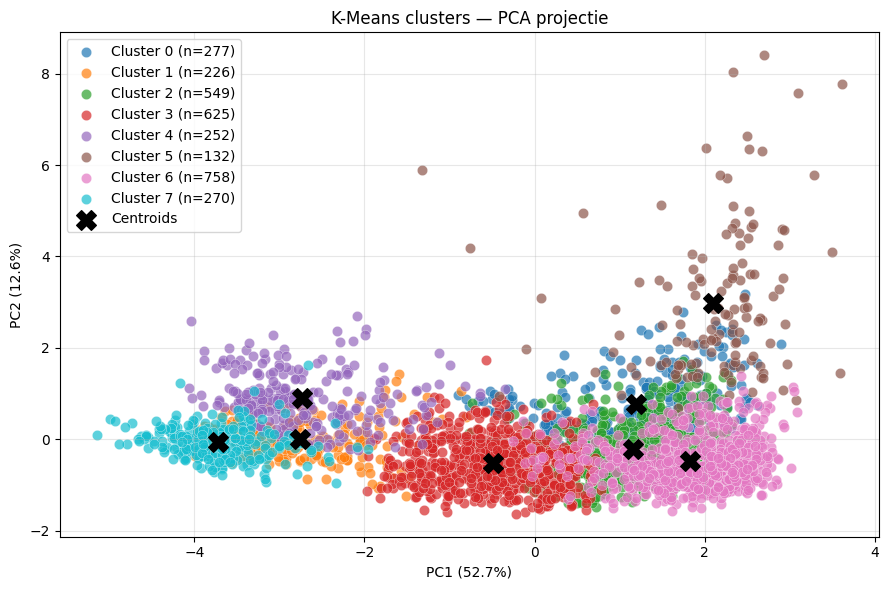

In [55]:
# ── PCA visualisatie (2D projectie van alle features) ────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"PCA verklaart {explained[0]*100:.1f}% + {explained[1]*100:.1f}% = {sum(explained)*100:.1f}% van de variantie")

colors = [
    '#1f77b4',  # helder blauw
    '#ff7f0e',  # oranje
    '#2ca02c',  # groen
    '#d62728',  # rood
    '#9467bd',  # paars
    '#8c564b',  # bruin
    '#e377c2',  # roze
    '#17becf'   # cyaan/turquoise
]


fig, ax = plt.subplots(figsize=(9, 6))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colors[c], label=f'Cluster {c} (n={mask.sum()})',
               alpha=0.7, edgecolors='white', linewidths=0.3, s=55)

# Cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           marker='X', s=200, color='black', zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('K-Means clusters — PCA projectie')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
pca.explained_variance_ratio_

array([0.52732878, 0.12574668])

In [56]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=features_available
)

print("\nPCA Loadings:")
print(loadings)


PCA Loadings:
                       PC1       PC2
tempo             0.177496  0.493015
energy            0.447289  0.048008
acousticness     -0.415522 -0.045830
valence           0.360485 -0.152833
loudness          0.436372 -0.067528
danceability      0.355888 -0.234189
instrumentalness -0.364088  0.170165
speechiness       0.127214  0.800507


In [57]:
for pc in loadings.columns:
    print(f"\nBelangrijkste features voor {pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))



Belangrijkste features voor PC1:
energy              0.447289
loudness            0.436372
acousticness        0.415522
instrumentalness    0.364088
valence             0.360485
Name: PC1, dtype: float64

Belangrijkste features voor PC2:
speechiness         0.800507
tempo               0.493015
danceability        0.234189
instrumentalness    0.170165
valence             0.152833
Name: PC2, dtype: float64


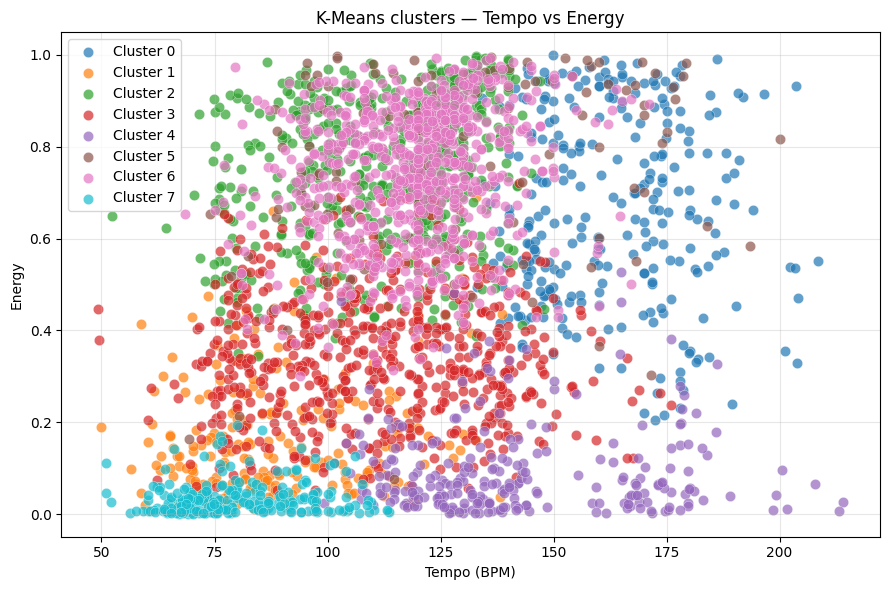

In [26]:
# ── Scatter: Tempo vs Energy ingekleurd per cluster ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
for c in range(N_CLUSTERS):
    mask = df_model['cluster'] == c
    ax.scatter(df_model.loc[mask, 'tempo'], df_model.loc[mask, 'energy'],
               color=colors[c], label=f'Cluster {c}',
               alpha=0.7, edgecolors='white', linewidths=0.3, s=55)

ax.set_xlabel('Tempo (BPM)')
ax.set_ylabel('Energy')
ax.set_title('K-Means clusters — Tempo vs Energy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Cluster labels interpreteren
Vul hier in welke cluster calm, neutral en energy is op basis van de gemiddelden hierboven.

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
#  PAS DIT AAN op basis van de cluster gemiddelden hierboven
# ══════════════════════════════════════════════════════════════════════════════
CLUSTER_NAMES = {
    7: 'calm',      # <-- verander naar de juiste naam
    1: 'neutral',   # <-- verander naar de juiste naam
    2: 'energy',    # <-- verander naar de juiste naam
    'x': 'others', 
}
# ══════════════════════════════════════════════════════════════════════════════

df_model['label'] = df_model['cluster'].map(CLUSTER_NAMES)

# Voeg naam kolommen toe aan het originele dataframe
df_result = df.loc[df_model.index].copy()
df_result['cluster'] = df_model['cluster']
df_result['label']   = df_model['label']

print("Songs per label:")
print(df_result['label'].value_counts().to_string())

# Preview
show_cols = [c for c in ['name', 'artists', 'tempo', 'energy', 'label'] if c in df_result.columns]
display(df_result[show_cols].head(10))

Songs per label:
label
energy     549
calm       270
neutral    226


,name,artists,tempo,energy,label
0,Freedom! '90 - Remastered,George Michael,91.703,0.863,NaN
1,Lovefool,The Cardigans,111.845,0.636,NaN
2,No Diggity,Blackstreet;Dr. Dre;Queen Pen,88.634,0.646,NaN
3,Shoop,Salt-N-Pepa,96.918,0.674,NaN
4,Praise You (Radio Edit),Fatboy Slim,109.722,0.884,energy
5,Remember Me - Original Mix,Blue Boy,100.875,0.689,NaN
6,It Feels So Good,Sonique,134.973,0.680,NaN
7,You Got The Love - New Voyager Radio Edit,The Source & Candi Staton;The Source;Candi Sta...,107.094,0.898,energy
8,Jump Around - 30 Years Remaster,House Of Pain,106.929,0.823,NaN
9,The Sign,Ace of Base,96.987,0.786,NaN


---
## 6. Model B — Random Forest Classifier
Getraind op de K-Means cluster labels. Leert welke combinatie van features een cluster voorspelt.

In [28]:
# ── Train/test split ──────────────────────────────────────────────────────────
X = df_model[features_available].values
y = df_model['cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)} songs")
print(f"Test : {len(X_test)} songs")

Train: 2316 songs
Test : 773 songs


In [29]:
# ── Random Forest trainen ─────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Cross-validatie score
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f"Cross-validatie accuracy (5-fold): {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

# Test score
y_pred = rf.predict(X_test)
print(f"Test accuracy                     : {(y_pred == y_test).mean():.3f}")

Cross-validatie accuracy (5-fold): 0.926 +/- 0.022
Test accuracy                     : 0.939


In [30]:
# ── Classification report ─────────────────────────────────────────────────────
label_names = [CLUSTER_NAMES[i] for i in sorted(CLUSTER_NAMES)]
print(classification_report(y_test, y_pred, target_names=label_names))

TypeError: '<' not supported between instances of 'str' and 'int'

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# ── Feature importance ────────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=features_available).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='#5b9bd5', edgecolor='white')
ax.set_xlabel('Belang')
ax.set_title('Random Forest — Feature Importance')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMeest bepalende features:")
print(importances.sort_values(ascending=False).to_string())

---
## 7. Vergelijking K-Means vs Random Forest

In [ ]:
# Beide modellen voorspellen op de volledige dataset
df_compare = df_model[features_available].copy()
df_compare['kmeans_cluster'] = cluster_labels
df_compare['rf_cluster']     = rf.predict(X_scaled)
df_compare['kmeans_label']   = df_compare['kmeans_cluster'].map(CLUSTER_NAMES)
df_compare['rf_label']       = df_compare['rf_cluster'].map(CLUSTER_NAMES)
df_compare['agree']          = df_compare['kmeans_cluster'] == df_compare['rf_cluster']

agreement = df_compare['agree'].mean()
print(f"Overeenstemming K-Means vs Random Forest: {agreement*100:.1f}%")
print(f"Verschillend geclassificeerd            : {(~df_compare['agree']).sum()} songs")

# Songs waar de twee modellen het oneens zijn
disagreed = df_compare[~df_compare['agree']]
show = [c for c in ['name', 'artists', 'tempo', 'energy', 'kmeans_label', 'rf_label'] if c in df_result.columns or c in disagreed.columns]

if len(disagreed) > 0:
    print(f"\nVoorbeeld van songs waarover de modellen verschillen:")
    combined_view = df_result.loc[disagreed.index, [c for c in ['name','artists','tempo','energy'] if c in df_result.columns]]
    combined_view = combined_view.join(disagreed[['kmeans_label','rf_label']])
    display(combined_view.head(10))

---
## 8. Resultaten opslaan

In [ ]:
OUTPUT_PATH = Path("classified_songs.csv")   # <-- pas aan indien nodig

df_result.to_csv(OUTPUT_PATH, index=False)
print(f"Opgeslagen: {OUTPUT_PATH}")
print(f"  {len(df_result)} songs met kolommen 'cluster' en 'label'")
print(f"\nVerdeling:")
print(df_result['label'].value_counts().to_string())